In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist


(train_X, train_y), (test_X, test_y) = fashion_mnist.load_data()
mask_train = (train_y == 0) | (train_y == 1)
X_train = train_X[mask_train].reshape(-1, 784) / 255.0
y_train = train_y[mask_train].reshape(-1, 1)

mask_test = (test_y == 0) | (test_y == 1)
X_test = test_X[mask_test].reshape(-1, 784) / 255.0
y_test = test_y[mask_test].reshape(-1, 1)

print(f"Data is ready! Training set size: {X_train.shape}")

Data is ready! Training set size: (12000, 784)


In [ ]:
def relu(z): return np.maximum(0, z)
def relu_derivative(z): return (z > 0).astype(float)
def sigmoid(z): return 1 / (1 + np.exp(-z))

def init_params(n_in=784, n_h=128, n_out=1):
    np.random.seed(42)

    return {
        "W1": np.random.randn(n_in, n_h) * np.sqrt(2.0 / n_in),
        "b1": np.zeros((1, n_h)),
        "W2": np.random.randn(n_h, n_out) * np.sqrt(2.0 / n_h),
        "b2": np.zeros((1, n_out))
    }

def forward_pass(X, p):
    Z1 = np.dot(X, p["W1"]) + p["b1"]
    A1 = relu(Z1)
    Z2 = np.dot(A1, p["W2"]) + p["b2"]
    A2 = sigmoid(Z2)
    return A2, {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}

def backward_pass(X, y, cache, p):
    m = X.shape[0]

    dZ2 = cache["A2"] - y
    dW2 = (1/m) * np.dot(cache["A1"].T, dZ2)
    db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)

    dA1 = np.dot(dZ2, p["W2"].T)
    dZ1 = dA1 * relu_derivative(cache["Z1"])
    dW1 = (1/m) * np.dot(X.T, dZ1)
    db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

Epoch 0, Loss: 0.8244
Epoch 10, Loss: 0.1664
Epoch 20, Loss: 0.1261
Epoch 30, Loss: 0.1057
Epoch 40, Loss: 0.0923
Epoch 50, Loss: 0.0828
Epoch 60, Loss: 0.0757
Epoch 70, Loss: 0.0704
Epoch 80, Loss: 0.0663
Epoch 90, Loss: 0.0631


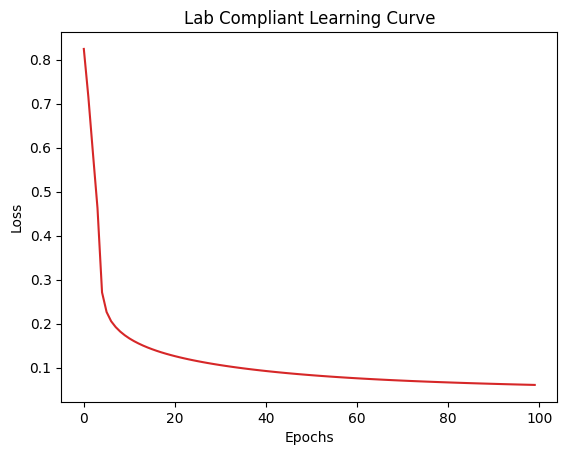


Final Training Accuracy: %98.22
Final Test Accuracy: %97.90


In [ ]:
params = init_params()
lr = 0.1
epochs = 100
loss_history = []

for i in range(epochs):
    A2, cache = forward_pass(X_train, params)

    loss = -np.mean(y_train * np.log(A2 + 1e-12) + (1 - y_train) * np.log(1 - A2 + 1e-12))
    loss_history.append(loss)

    grads = backward_pass(X_train, y_train, cache, params)


    for k in params: params[k] -= lr * grads["d" + k]

    if i % 10 == 0: print(f"Epoch {i}, Loss: {loss:.4f}")


plt.plot(loss_history, color='tab:red')
plt.title("Lab Compliant Learning Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()


def get_accuracy(X, y, p):
    predictions, _ = forward_pass(X, p)
    predicted_classes = (predictions > 0.5).astype(int)
    return np.mean(predicted_classes == y) * 100

print(f"\nFinal Training Accuracy: %{get_accuracy(X_train, y_train, params):.2f}")
print(f"Final Test Accuracy: %{get_accuracy(X_test, y_test, params):.2f}")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


class FashionMLP(nn.Module):
    def __init__(self):
        super(FashionMLP, self).__init__()

        self.fc1 = nn.Linear(784, 128)

        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):

        x = F.relu(self.fc1(x))

        x = torch.sigmoid(self.fc2(x))
        return x

pytorch_model = FashionMLP()
print(pytorch_model)

FashionMLP(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)


In [ ]:

criterion = nn.BCELoss()
optimizer = optim.SGD(pytorch_model.parameters(), lr=0.1)


X_train_pt = torch.tensor(X_train, dtype=torch.float32)
y_train_pt = torch.tensor(y_train, dtype=torch.float32)


epochs = 100
pt_loss_history = []

for epoch in range(epochs):

    outputs = pytorch_model(X_train_pt)
    loss = criterion(outputs, y_train_pt)


    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    pt_loss_history.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

print("PyTorch Training Completed!")

Epoch 0, Loss: 0.7178
Epoch 10, Loss: 0.3444
Epoch 20, Loss: 0.1849
Epoch 30, Loss: 0.1407
Epoch 40, Loss: 0.1190
Epoch 50, Loss: 0.1044
Epoch 60, Loss: 0.0935
Epoch 70, Loss: 0.0851
Epoch 80, Loss: 0.0785
Epoch 90, Loss: 0.0734
PyTorch Training Completed!


In [ ]:

pytorch_model.eval()
with torch.no_grad():
    X_test_pt = torch.tensor(X_test, dtype=torch.float32)
    y_test_pt = torch.tensor(y_test, dtype=torch.float32)

    pt_preds = pytorch_model(X_test_pt)
    pt_predicted_classes = (pt_preds > 0.5).float()
    pt_test_acc = (pt_predicted_classes == y_test_pt).float().mean() * 100

print(f"--- COMPARISON ---")
print(f"NumPy Test Accuracy: %{get_accuracy(X_test, y_test, params):.2f}")
print(f"PyTorch Test Accuracy: %{pt_test_acc.item():.2f}")

--- COMPARISON ---
NumPy Test Accuracy: %97.90
PyTorch Test Accuracy: %97.65
